# Healthcare Claims & Denials Analysis (Python / pandas)

**Author:** Hanspal Singh — Data Analyst · Microsoft PL-300 Certified

Analysing 5,000+ healthcare claims to answer: **how much revenue is lost to denials, why, and how much is recoverable.**
Built with Python + pandas + matplotlib. Data is synthetic (not real patient/payer data).


## 1. Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 2. Load the data


In [2]:
df = pd.read_csv('data/claims_data.csv', parse_dates=['date_of_service'])
print(df.shape)
df.head()


(5025, 13)


,claim_id,date_of_service,payer_name,service_type,billed_amount,allowed_amount,paid_amount,denied_amount,claim_status,denial_category,denial_type,appeal_status,aging_days
0,CLM100000,2025-02-02,Kaiser,NaN,564.94,353.50,155.16,409.78,Partially Paid,Timely Filing,Hard,Not Appealed,113.00
1,CLM100001,2025-10-10,Aetna,Physical Therapy,533.44,344.55,344.55,0.00,Paid,NaN,NaN,Not Appealed,29.00
2,CLM100002,2025-08-27,UNITEDHEALTHCARE,Radiology,"1,259.26",708.46,708.46,0.00,Paid,NaN,NaN,Not Appealed,15.00
3,CLM100003,2025-06-10,Humana,Emergency,"1,304.24",657.53,657.53,0.00,Paid,NaN,NaN,Not Appealed,19.00
4,CLM100004,2025-06-08,Medicare,Surgery,505.44,313.80,313.80,0.00,Paid,NaN,NaN,Not Appealed,15.00


## 3. First look
Understand structure, types, and summary stats before touching anything.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   claim_id         5025 non-null   object        
 1   date_of_service  5025 non-null   datetime64[ns]
 2   payer_name       5025 non-null   object        
 3   service_type     4965 non-null   object        
 4   billed_amount    5025 non-null   float64       
 5   allowed_amount   5025 non-null   float64       
 6   paid_amount      5025 non-null   float64       
 7   denied_amount    5025 non-null   float64       
 8   claim_status     5025 non-null   object        
 9   denial_category  1939 non-null   object        
 10  denial_type      1939 non-null   object        
 11  appeal_status    5025 non-null   object        
 12  aging_days       4985 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(7)
memory usage: 510.5+ KB


In [4]:
df.describe()


,date_of_service,billed_amount,allowed_amount,paid_amount,denied_amount,aging_days
count,5025,"5,025.00","5,025.00","5,025.00","5,025.00","4,985.00"
mean,2025-07-01 08:17:11.641791232,949.98,619.36,434.22,312.88,45.59
min,2025-01-01 00:00:00,34.04,22.51,0.00,0.00,1.00
25%,2025-04-01 00:00:00,461.72,293.12,27.01,0.00,16.00
50%,2025-06-30 00:00:00,733.55,472.86,320.73,0.00,32.00
75%,2025-10-02 00:00:00,"1,189.00",772.60,596.82,465.76,60.00
max,2025-12-31 00:00:00,"8,248.88","6,950.59","6,950.59","7,256.97",159.00
std,NaN,759.37,516.91,500.96,579.40,41.19


## 4. Data cleaning
Real data is messy. We check for: duplicates, missing values, and inconsistent payer names.


In [5]:
# 4a. Duplicate rows
print('Duplicates:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)


Duplicates: 25


In [6]:
# 4b. Missing values per column
df.isna().sum()


claim_id              0
date_of_service       0
payer_name            0
service_type         60
billed_amount         0
allowed_amount        0
paid_amount           0
denied_amount         0
claim_status          0
denial_category    3072
denial_type        3072
appeal_status         0
aging_days           40
dtype: int64

In [7]:
# 4c. Fill missing service_type and aging_days sensibly
df['service_type'] = df['service_type'].fillna('Unknown')
df['aging_days'] = df['aging_days'].fillna(df['aging_days'].median())


In [ ]:
# 4d. Normalise messy payer names (e.g. 'UNITEDHEALTHCARE', 'United Healthcare' -> one value)
df['payer_name'] = (df['payer_name'].str.strip().str.replace(r'\s+',' ', regex=True)
                    .str.title())
df['payer_name'] = df['payer_name'].replace({
    'Bcbs': 'Blue Cross Blue Shield',
    'Unitedhealthcare': 'UnitedHealthcare',   # merge the two United spellings
    'United Healthcare': 'UnitedHealthcare',
})
df['payer_name'].value_counts()

## 5. Derived column — aging buckets
Group aging_days into standard A/R buckets (like a revenue-cycle report).


In [9]:
bins=[0,30,60,90,10000]; labels=['0-30','31-60','61-90','90+']
df['aging_bucket'] = pd.cut(df['aging_days'], bins=bins, labels=labels, right=True)
df['aging_bucket'].value_counts().reindex(labels)


aging_bucket
0-30     2365
31-60    1396
61-90     388
90+       851
Name: count, dtype: int64

## 6. Key RCM metrics (KPIs)
The numbers a revenue-cycle team actually cares about.

*Note: here **Denial Rate** counts any claim not fully paid (Denied + Partially Paid).*


In [10]:
total_billed = df['billed_amount'].sum()
total_paid   = df['paid_amount'].sum()
total_denied = df['denied_amount'].sum()

net_collection_rate = total_paid / df['allowed_amount'].sum()
denial_rate = (df['claim_status'] != 'Paid').mean()
soft_denied_recoverable = df.loc[df['denial_type']=='Soft','denied_amount'].sum()

print(f'Total Billed:            ${total_billed:,.0f}')
print(f'Total Paid:              ${total_paid:,.0f}')
print(f'Total Denied:            ${total_denied:,.0f}')
print(f'Net Collection Rate:     {net_collection_rate:.1%}')
print(f'Denial Rate:             {denial_rate:.1%}')
print(f'Soft (Recoverable) $:    ${soft_denied_recoverable:,.0f}')


Total Billed:            $4,750,593
Total Paid:              $2,172,569
Total Denied:            $1,562,699
Net Collection Rate:     70.1%
Denial Rate:             38.6%
Soft (Recoverable) $:    $911,317


## 7. Denial analysis — *why* are claims denied?


In [11]:
denials = df[df['denied_amount']>0]
by_cat = denials.groupby('denial_category')['denied_amount'].sum().sort_values(ascending=False)
by_cat


denial_category
Prior Authorization Missing   304,656.91
Coding Error                  229,958.89
Missing Information           228,134.84
Timely Filing                 209,936.54
Medical Necessity             184,529.48
Coordination of Benefits      148,566.74
Non-Covered Service           146,614.74
Duplicate Claim               110,301.15
Name: denied_amount, dtype: float64

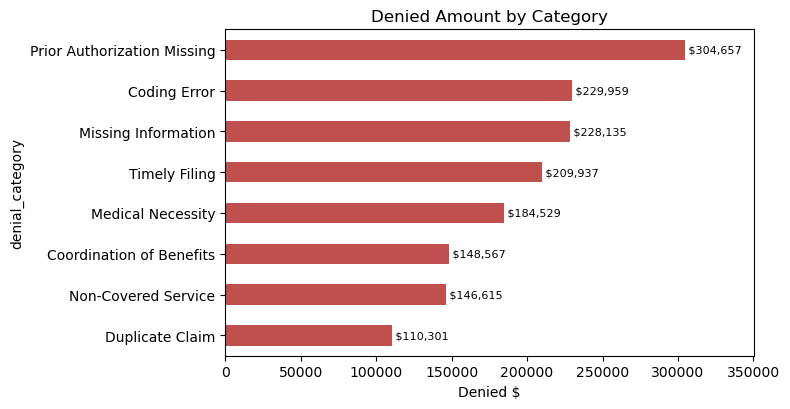

In [12]:
# Chart: denied $ by category (largest on top, with value labels)
chart = by_cat.sort_values()          # ascending so the largest bar plots at the TOP
ax = chart.plot(kind='barh', figsize=(8,4.2), color='#c0504d')
ax.set_title('Denied Amount by Category'); ax.set_xlabel('Denied $')
for i, v in enumerate(chart):
    ax.text(v, i, f' ${v:,.0f}', va='center', fontsize=8)
ax.margins(x=0.15)                     # leave room for the labels
plt.tight_layout(); plt.show()


In [13]:
# Denial rate by payer (share of claims not fully paid)
df['is_denied'] = df['claim_status'].ne('Paid')
df.groupby('payer_name')['is_denied'].mean().sort_values(ascending=False)


payer_name
Blue Cross Blue Shield   0.42
Medicaid                 0.41
Kaiser                   0.40
Medicare                 0.39
Unitedhealthcare         0.39
United Healthcare        0.37
Aetna                    0.36
Cigna                    0.36
Humana                   0.36
Name: is_denied, dtype: float64

In [ ]:
# Chart: denial rate by payer
pr = (df.groupby('payer_name')['is_denied'].mean()*100).sort_values()
ax = pr.plot(kind='barh', figsize=(9,4.5), color='#8064a2')
ax.set_title('Denial Rate by Payer'); ax.set_xlabel('% of claims not fully paid')
for i, v in enumerate(pr): ax.text(v + 0.3, i, f'{v:.0f}%', va='center')
plt.tight_layout(); plt.savefig('charts/denial_rate_by_payer.png', dpi=120, bbox_inches='tight'); plt.show()

## 8. Appeal recovery — how much denied money comes back?
Soft denials can be appealed. Here's the recovery so far, and the *unappealed* opportunity.


In [15]:
won      = denials.loc[denials['appeal_status']=='Appeal Won', 'denied_amount'].sum()
appealed = denials.loc[denials['appeal_status'].isin(['Appeal Won','Appeal Lost','Appealed - Pending']), 'denied_amount'].sum()
not_appealed_soft = denials.loc[(denials['denial_type']=='Soft') & (denials['appeal_status']=='Not Appealed'), 'denied_amount'].sum()

print(f'Appeal win rate ($):                  {won/appealed:.1%}')
print(f'Recovered via appeals:               ${won:,.0f}')
print(f'Soft denials NOT yet appealed (opp):  ${not_appealed_soft:,.0f}')

denials.groupby('appeal_status')['denied_amount'].sum().sort_values(ascending=False)


Appeal win rate ($):                  32.7%
Recovered via appeals:               $235,095
Soft denials NOT yet appealed (opp):  $394,915


appeal_status
Not Appealed         842,660.29
Appeal Lost          297,512.41
Appeal Won           235,094.62
Appealed - Pending   187,431.97
Name: denied_amount, dtype: float64

## 9. Aging analysis — where is the A/R stuck?


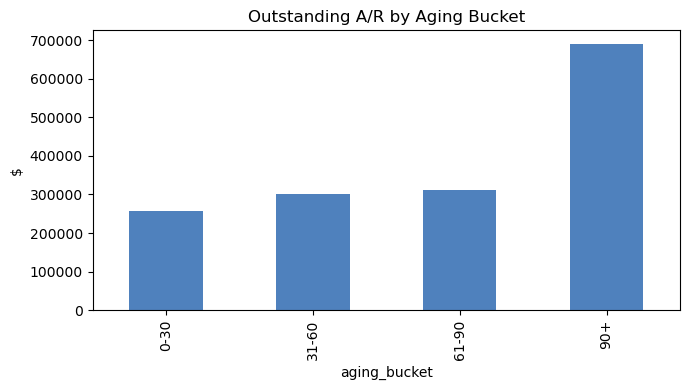

In [16]:
ar = df[df['claim_status']!='Paid'].groupby('aging_bucket', observed=True)['denied_amount'].sum().reindex(labels)
ax = ar.plot(kind='bar', figsize=(7,4), color='#4f81bd')
ax.set_title('Outstanding A/R by Aging Bucket'); ax.set_ylabel('$')
plt.tight_layout(); plt.show()


## 10. Trend — billed vs paid over time


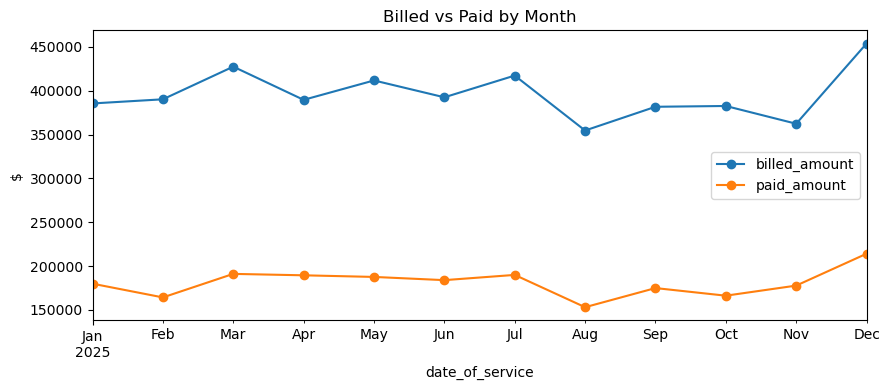

In [17]:
m = df.set_index('date_of_service').resample('ME')[['billed_amount','paid_amount']].sum()
ax = m.plot(figsize=(9,4), marker='o')
ax.set_title('Billed vs Paid by Month'); ax.set_ylabel('$')
plt.tight_layout(); plt.show()


## 11. Insights & recommendation

- Denial rate is **39%**; **\$911,317** of denied dollars are **soft (recoverable)**.
- Denials concentrate in **Prior Authorization Missing** claims and the payer **Blue Cross Blue Shield**.
- **44%** of outstanding A/R sits in the **90+ day** bucket — money aging past the point it's easy to collect.
- Of the recoverable soft denials, **\$394,915 has not been appealed yet** — the clearest untapped recovery opportunity. (Appeals that *were* filed won **33%**, recovering **\$235,095**.)

**Recommendation:** Prioritise appeals on **Prior Authorization Missing** denials — the largest recoverable bucket, so the most revenue for the least effort. Start with **Blue Cross Blue Shield**, which has the highest denial rate.


## What I practised here
Loading & inspecting data · cleaning (dupes, nulls, text normalisation) · derived columns ·
groupby aggregations · time resampling · matplotlib charts — the core pandas analyst toolkit.
